### **ANALIZANDO TABLA PRIMARIA**

In [3]:
import pandas as pd
import numpy as np

# Definir tipos de datos reducidos para optimizar el uso de RAM desde la carga
dtypes_optimizados = {
    'SK_ID_CURR': 'int32',
    'TARGET': 'int8',
    'NAME_CONTRACT_TYPE': 'category',
    'CODE_GENDER': 'category',
    'FLAG_OWN_CAR': 'category',
    'FLAG_OWN_REALTY': 'category'
}

# Cargar la tabla principal desde la carpeta raw
df_train = pd.read_csv('../data/raw/application_train.csv', dtype=dtypes_optimizados)

# Verificar dimensiones y evaluar el consumo exacto de memoria RAM
print(f"Dimensiones del dataset principal: {df_train.shape}")
print("\nInformación de consumo de memoria:")
df_train.info(memory_usage='deep')

Dimensiones del dataset principal: (307511, 122)

Información de consumo de memoria:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: category(4), float64(65), int32(1), int64(39), int8(1), str(12)
memory usage: 441.5 MB


Muestra de datos financieros clave:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT
0,100002,1,Cash loans,M,202500.0,406597.5
1,100003,0,Cash loans,F,270000.0,1293502.5
2,100004,0,Revolving loans,M,67500.0,135000.0
3,100006,0,Cash loans,F,135000.0,312682.5
4,100007,0,Cash loans,M,121500.0,513000.0


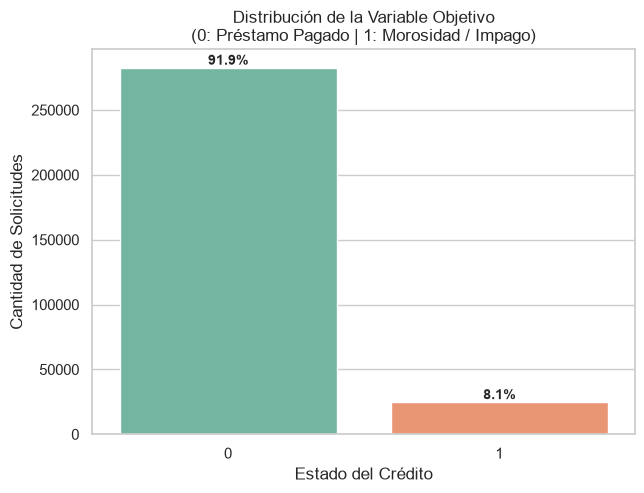

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# 1. Visualizar una muestra de las columnas financieras clave
columnas_clave = ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']
print("Muestra de datos financieros clave:")
display(df_train[columnas_clave].head())

# 2. Graficar el desbalance de la variable objetivo
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_train, x='TARGET', hue='TARGET', palette='Set2', legend=False)
plt.title('Distribución de la Variable Objetivo\n(0: Préstamo Pagado | 1: Morosidad / Impago)', fontsize=12)
plt.xlabel('Estado del Crédito')
plt.ylabel('Cantidad de Solicitudes')

# Añadir las etiquetas de porcentaje sobre cada barra
total = len(df_train)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

In [5]:
# Calcular el porcentaje exacto de valores nulos por columna
nulos = df_train.isnull().mean() * 100
# Filtrar solo las que tienen nulos y ordenarlas de mayor a menor
nulos = nulos[nulos > 0].sort_values(ascending=False)

print(f"Total de columnas con valores nulos: {len(nulos)} de {df_train.shape[1]}")
print("\nTop 20 columnas con mayor porcentaje de datos faltantes:")
# Mostrar como un dataframe con formato de porcentaje
display(nulos.head(20).to_frame(name='Porcentaje de Nulos').style.format("{:.2f}%"))

Total de columnas con valores nulos: 67 de 122

Top 20 columnas con mayor porcentaje de datos faltantes:


,Porcentaje de Nulos
COMMONAREA_MEDI,69.87%
COMMONAREA_MODE,69.87%
COMMONAREA_AVG,69.87%
NONLIVINGAPARTMENTS_MODE,69.43%
NONLIVINGAPARTMENTS_MEDI,69.43%
NONLIVINGAPARTMENTS_AVG,69.43%
FONDKAPREMONT_MODE,68.39%
LIVINGAPARTMENTS_AVG,68.35%
LIVINGAPARTMENTS_MEDI,68.35%
LIVINGAPARTMENTS_MODE,68.35%


In [6]:
# Analizar las variables EXT_SOURCE
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]

print("Porcentaje de nulos en los scores externos:")
display(ext_data.isnull().mean().to_frame(name='Porcentaje de Nulos').style.format("{:.2%}"))

# Calcular correlación con TARGET
correlaciones = ext_data.corr()['TARGET'].sort_values()

print("\nCorrelación de los scores externos con la morosidad (TARGET):")
display(correlaciones.to_frame(name='Correlación de Pearson'))

Porcentaje de nulos en los scores externos:


,Porcentaje de Nulos
TARGET,0.00%
EXT_SOURCE_1,56.38%
EXT_SOURCE_2,0.21%
EXT_SOURCE_3,19.83%



Correlación de los scores externos con la morosidad (TARGET):


,Correlación de Pearson
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
TARGET,1.000000


### **ANALIZANDO TABLAS SECUNDARIAS**

In [7]:
import os

# Lista de las 6 tablas relacionales secundarias
tablas_secundarias = [
    'bureau.csv', 
    'bureau_balance.csv', 
    'previous_application.csv',
    'POS_CASH_balance.csv', 
    'installments_payments.csv', 
    'credit_card_balance.csv'
]

print("Mapeo de Tablas Secundarias (Historial Relacional):\n" + "-"*55)

peso_total_mb = 0

for tabla in tablas_secundarias:
    ruta = f'../data/raw/{tabla}'
    if os.path.exists(ruta):
        # Leer solo una muestra para ver las columnas y cargar la estructura completa para el tamaño
        df_temp = pd.read_csv(ruta)
        filas, columnas = df_temp.shape
        memoria_mb = df_temp.memory_usage(deep=True).sum() / (1024 * 1024)
        peso_total_mb += memoria_mb
        
        # Identificar qué llaves de conexión tiene esta tabla
        llaves = [col for col in ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV'] if col in df_temp.columns]
        
        print(f"Archivo: {tabla}")
        print(f"Dimensiones: {filas:,} filas x {columnas} columnas")
        print(f"Llaves de conexión: {llaves}")
        print(f"Consumo en RAM: {memoria_mb:.2f} MB\n")

print("-" * 55)
print(f"Peso total estimado en memoria de las tablas secundarias: {peso_total_mb:.2f} MB")

Mapeo de Tablas Secundarias (Historial Relacional):
-------------------------------------------------------
Archivo: bureau.csv
Dimensiones: 1,716,428 filas x 17 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_BUREAU']
Consumo en RAM: 472.82 MB

Archivo: bureau_balance.csv
Dimensiones: 27,299,925 filas x 3 columnas
Llaves de conexión: ['SK_ID_BUREAU']
Consumo en RAM: 1718.33 MB

Archivo: previous_application.csv
Dimensiones: 1,670,214 filas x 37 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 1703.01 MB

Archivo: POS_CASH_balance.csv
Dimensiones: 10,001,358 filas x 8 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 1060.95 MB

Archivo: installments_payments.csv
Dimensiones: 13,605,401 filas x 8 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 830.41 MB

Archivo: credit_card_balance.csv
Dimensiones: 3,840,312 filas x 23 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 846.39 MB

-----

### **6. INTEGRIDAD DE LLAVES Y OBJETIVO (Sec 7.3)**
Verifica unicidad de SK_ID_CURR, valores de TARGET y tipos str candidatas a category.

In [16]:
print(f"Filas: {len(df_train):,} | SK_ID_CURR unicos: {df_train['SK_ID_CURR'].nunique():,} | Duplicados: {df_train.duplicated('SK_ID_CURR').sum():,}")
print("\nDistribucion TARGET (0=pago, 1=mora):")
print(df_train['TARGET'].value_counts())
print(f"Tasa mora: {df_train['TARGET'].mean():.4f} ({df_train['TARGET'].sum():,} / {len(df_train):,})")
print("\nNulos en llaves/objetivo:")
print(df_train[['SK_ID_CURR', 'TARGET']].isnull().sum())
str_cols = df_train.select_dtypes(include=['str', 'object', 'string']).columns.tolist()
print(f"\nColumnas str pendientes de category ({len(str_cols)}): {str_cols}")
print("\nConteo por dtype:")
print(df_train.dtypes.value_counts())

Filas: 307,511 | SK_ID_CURR unicos: 307,511 | Duplicados: 0

Distribucion TARGET (0=pago, 1=mora):
TARGET
0    282686
1     24825
Name: count, dtype: int64
Tasa mora: 0.0807 (24,825 / 307,511)

Nulos en llaves/objetivo:
SK_ID_CURR    0
TARGET        0
dtype: int64

Columnas str pendientes de category (12): ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Conteo por dtype:
float64     68
int64       39
str         12
int8         2
category     2
int32        1
category     1
category     1
Name: count, dtype: int64


### **7. VARIABLES FINANCIERAS Y RATIOS (Pregunta negocio 1)**
Capacidad de pago: descriptivos, outliers y ratios CREDITO/INGRESO y ANUALIDAD/INGRESO vs TARGET.

                     count           mean            std      min       50%  \
AMT_INCOME_TOTAL  307511.0  168797.919297  237123.146279  25650.0  147150.0   
AMT_CREDIT        307511.0  599025.999706  402490.776996  45000.0  513531.0   
AMT_ANNUITY       307499.0   27108.573909   14493.737315   1615.5   24903.0   
AMT_GOODS_PRICE   307233.0  538396.207429  369446.460540  40500.0  450000.0   

                        90%        99%          max  
AMT_INCOME_TOTAL   270000.0   472500.0  117000000.0  
AMT_CREDIT        1133748.0  1854000.0    4050000.0  
AMT_ANNUITY         45954.0    70006.5     258025.5  
AMT_GOODS_PRICE   1093500.0  1800000.0    4050000.0  

Mediana de ratios por TARGET:
        RATIO_CREDITO_INGRESO  RATIO_ANUALIDAD_INGRESO
TARGET                                                
0                    3.266653                 0.162280
1                    3.253143                 0.169294


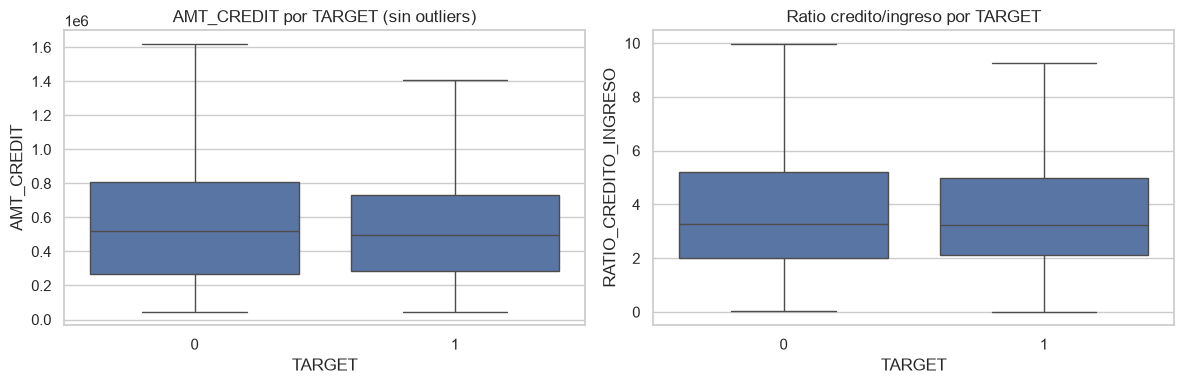

In [17]:
fin = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
print(df_train[fin].describe(percentiles=[0.5, 0.9, 0.99]).T)
df_train['RATIO_CREDITO_INGRESO'] = df_train['AMT_CREDIT'] / df_train['AMT_INCOME_TOTAL']
df_train['RATIO_ANUALIDAD_INGRESO'] = df_train['AMT_ANNUITY'] / df_train['AMT_INCOME_TOTAL']
print("\nMediana de ratios por TARGET:")
print(df_train.groupby('TARGET', observed=True)[['RATIO_CREDITO_INGRESO', 'RATIO_ANUALIDAD_INGRESO']].median())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_train, x='TARGET', y='AMT_CREDIT', ax=axes[0], showfliers=False)
axes[0].set_title('AMT_CREDIT por TARGET (sin outliers)')
sns.boxplot(data=df_train, x='TARGET', y='RATIO_CREDITO_INGRESO', ax=axes[1], showfliers=False)
axes[1].set_title('Ratio credito/ingreso por TARGET')
plt.tight_layout(); plt.show()

### **8.1 CONTRATO Y GENERO (auditoria prioritaria)**
Tasa mora Cash vs Revolving y M vs F (paridad F/M). Chi2 por grupo. Aqui se define tasa_mora() para 8.2-8.4.


NAME_CONTRACT_TYPE (2 grupos) - tasa mora por grupo:
Cash loans: 8.35% (n=278232)
Revolving loans: 5.48% (n=29279)
chi2 p-value: 1.024e-65

CODE_GENDER (3 grupos) - tasa mora por grupo:
M: 10.14% (n=105059)
F: 7.00% (n=202448)
XNA: 0.00% (n=4)
chi2 p-value: 1.129e-200


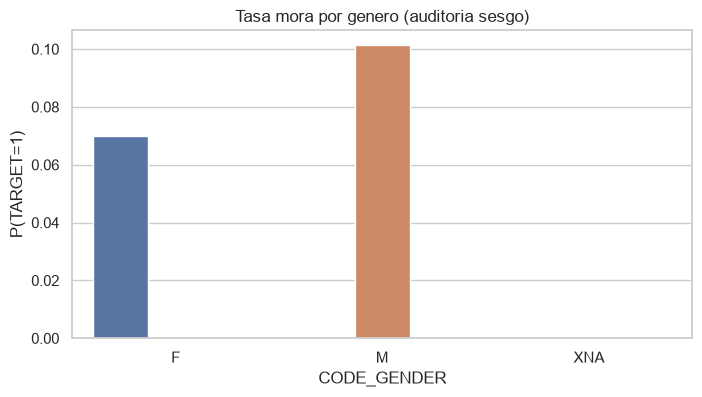

In [33]:
from scipy.stats import chi2_contingency
pd.set_option('display.width', 200, 'display.max_rows', 50)
def tasa_mora(col):
    s = df_train[col].astype("category")
    t = df_train.groupby(s, observed=True)['TARGET'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(f"\n{col} ({t.shape[0]} grupos) - tasa mora por grupo:")
    for idx, r in t.iterrows():
        print(f"{idx}: {100 * r['mean']:.2f}% (n={r['count']:.0f})")
    try:
        ct = pd.crosstab(s, df_train['TARGET'])
        print(f"chi2 p-value: {chi2_contingency(ct)[1]:.4g}")
    except Exception as e:
        print(f"chi2 no aplica: {e}")
for c in ['NAME_CONTRACT_TYPE', 'CODE_GENDER']:
    tasa_mora(c)
plt.figure(figsize=(8, 4))
sns.barplot(data=df_train, x='CODE_GENDER', y='TARGET', hue='CODE_GENDER', legend=False, errorbar=None)
plt.title('Tasa mora por genero (auditoria sesgo)')
plt.ylabel('P(TARGET=1)'); plt.show()

### **8.2 ACTIVOS: AUTO Y VIVIENDA PROPIA (Y/N)**
Solo 2 filas por tabla. Y/N limpio de FLAG_OWN_REALTY.

In [34]:
# tasa_mora() definida en 8.1 (ejecutar celdas en orden)
for c in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    tasa_mora(c)


FLAG_OWN_CAR (2 grupos) - tasa mora por grupo:
N: 8.50% (n=202924)
Y: 7.24% (n=104587)
chi2 p-value: 9.331e-34

FLAG_OWN_REALTY (2 grupos) - tasa mora por grupo:
N: 8.32% (n=94199)
Y: 7.96% (n=213312)
chi2 p-value: 0.0006681


### **8.3 FAMILIA Y TIPO DE VIVIENDA**
Tablas de 6 filas con to_string() para evitar el '...' del output.

In [35]:
# tasa_mora() definida en 8.1 (ejecutar celdas en orden)
for c in ['NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']:
    tasa_mora(c)


NAME_FAMILY_STATUS (6 grupos) - tasa mora por grupo:
Civil marriage: 9.94% (n=29775)
Single / not married: 9.81% (n=45444)
Separated: 8.19% (n=19770)
Married: 7.56% (n=196432)
Widow: 5.82% (n=16088)
Unknown: 0.00% (n=2)
chi2 p-value: 7.745e-107

NAME_HOUSING_TYPE (6 grupos) - tasa mora por grupo:
Rented apartment: 12.31% (n=4881)
With parents: 11.70% (n=14840)
Municipal apartment: 8.54% (n=11183)
Co-op apartment: 7.93% (n=1122)
House / apartment: 7.80% (n=272868)
Office apartment: 6.57% (n=2617)
chi2 p-value: 1.099e-88


### **8.4 NIVEL EDUCATIVO (auditoria sesgo socioeconomico)**
Solo NAME_EDUCATION_TYPE (5 niveles) + barplot para auditoria de sesgo.


NAME_EDUCATION_TYPE (5 grupos) - tasa mora por grupo:
Lower secondary: 10.93% (n=3816)
Secondary / secondary special: 8.94% (n=218391)
Incomplete higher: 8.48% (n=10277)
Higher education: 5.36% (n=74863)
Academic degree: 1.83% (n=164)
chi2 p-value: 2.448e-219


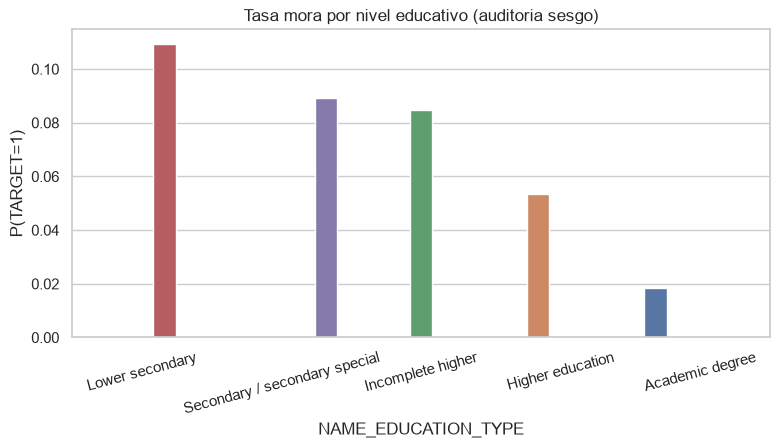

In [36]:
# tasa_mora() definida en 8.1 (ejecutar celdas en orden)
tasa_mora('NAME_EDUCATION_TYPE')
plt.figure(figsize=(9, 4))
sns.barplot(data=df_train, x='NAME_EDUCATION_TYPE', y='TARGET', hue='NAME_EDUCATION_TYPE', legend=False, errorbar=None, order=df_train.groupby('NAME_EDUCATION_TYPE', observed=True)['TARGET'].mean().sort_values(ascending=False).index)
plt.title('Tasa mora por nivel educativo (auditoria sesgo)')
plt.ylabel('P(TARGET=1)'); plt.xticks(rotation=15); plt.show()

### **9. TEMPORALES: EDAD Y ANTIGUEDAD LABORAL (Sec 6.2)**
DAYS_BIRTH a anios; DAYS_EMPLOYED centinela 365243 = sin empleo registrado.

           count       mean        std        min        max
TARGET                                                      
0       282686.0  44.183919  11.948531  20.503765  69.073238
1        24825.0  40.752438  11.479383  21.021218  68.906229

DAYS_EMPLOYED==365243 (centinela): 55,374 (18.01%)
FLAG_NO_EMPLEADO
0    0.086600
1    0.053996
Name: TARGET, dtype: float64

Correlacion vs TARGET:
EDAD_ANIOS          -0.078239
DAYS_EMPLOYED       -0.044932
DAYS_REGISTRATION    0.041975
DAYS_ID_PUBLISH      0.051457
Name: TARGET, dtype: float64


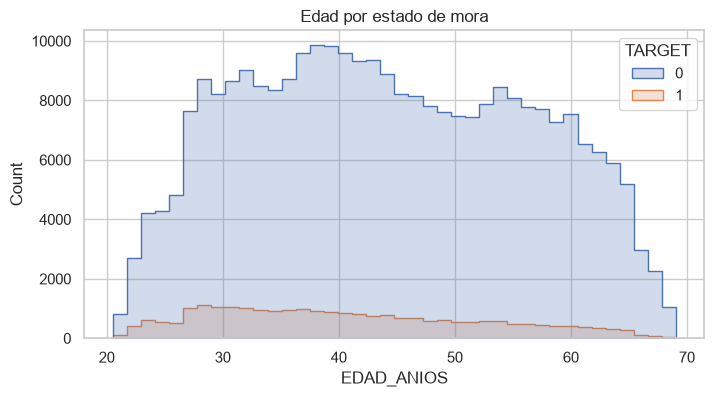

In [19]:
df_train['EDAD_ANIOS'] = -df_train['DAYS_BIRTH'] / 365.25
print(df_train.groupby('TARGET', observed=True)['EDAD_ANIOS'].describe()[['count', 'mean', 'std', 'min', 'max']])
n_cent = (df_train['DAYS_EMPLOYED'] == 365243).sum()
print(f"\nDAYS_EMPLOYED==365243 (centinela): {n_cent:,} ({100 * n_cent / len(df_train):.2f}%)")
df_train['FLAG_NO_EMPLEADO'] = (df_train['DAYS_EMPLOYED'] == 365243).astype('int8')
print(df_train.groupby('FLAG_NO_EMPLEADO', observed=True)['TARGET'].mean())
temp_cols = [c for c in ['EDAD_ANIOS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH'] if c in df_train.columns]
print("\nCorrelacion vs TARGET:")
print(df_train[temp_cols + ['TARGET']].corr(numeric_only=True)['TARGET'].drop('TARGET'))
plt.figure(figsize=(8, 4))
sns.histplot(data=df_train, x='EDAD_ANIOS', hue='TARGET', bins=40, element='step')
plt.title('Edad por estado de mora'); plt.show()

### **10. CIERRE FASE 1: BASELINE DUMMY Y DECISIONES A FASE 2**
Justifica ROC-AUC >= 0.75 (accuracy invalido) y deja decisiones vinculantes.

In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score
y = df_train['TARGET']
y_dummy = pd.Series(0, index=y.index)
print(f"Baseline siempre-0: accuracy={accuracy_score(y, y_dummy):.4f} (enganoso por 91.9% mayoritaria) | ROC-AUC={roc_auc_score(y, y_dummy):.4f}")
print("Umbral exito: ROC-AUC>=0.75 | Salida si <0.70 tras Fase 5 | Costos FN=S/1800 FP=S/150")
print("\nDECISIONES A FASE 2: "
      "\n(1) No imputar con media/moda; flag FALTA_X + LightGBM nativo NaN. "
      "\n(2) Agregar 6 secundarias por SK_ID_CURR a Parquet antes de joins. "
      "\n(3) Split estratificado previo anti-leakage. "
      "\n(4) Auditar sensibles paridad>=0.8.")

Baseline siempre-0: accuracy=0.9193 (enganoso por 91.9% mayoritaria) | ROC-AUC=0.5000
Umbral exito: ROC-AUC>=0.75 | Salida si <0.70 tras Fase 5 | Costos FN=S/1800 FP=S/150

DECISIONES A FASE 2: 
(1) No imputar con media/moda; flag FALTA_X + LightGBM nativo NaN. 
(2) Agregar 6 secundarias por SK_ID_CURR a Parquet antes de joins. 
(3) Split estratificado previo anti-leakage. 
(4) Auditar sensibles paridad>=0.8.
